In [1]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1


In [2]:
import pandas as pd

df = pd.read_csv("BankChurners.csv")

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
columns_to_remove = [
    "CLIENTNUM",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
]

df = df.drop(columns=columns_to_remove, errors="ignore")

print("Remaining columns:", df.shape[1])

Remaining columns: 20


In [4]:
df["Avg_Transaction_Amount"] = (
    df["Total_Trans_Amt"] / df["Total_Trans_Ct"]
)

df["High_Inactivity"] = (
    df["Months_Inactive_12_mon"] >= 3
).astype(int)

df["Transaction_Activity"] = (
    df["Total_Trans_Ct"] * df["Total_Trans_Amt"]
)

print("Engineered features created successfully.")

df[
    [
        "Avg_Transaction_Amount",
        "High_Inactivity",
        "Transaction_Activity"
    ]
].head()

Engineered features created successfully.


,Avg_Transaction_Amount,High_Inactivity,Transaction_Activity
0,27.238095,0,48048
1,39.121212,0,42603
2,94.350000,0,37740
3,58.550000,1,23420
4,29.142857,0,22848


In [5]:
X = df.drop(columns=["Attrition_Flag"])
y = df["Attrition_Flag"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10127, 22)
Target shape: (10127,)


In [6]:
y = y.map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

print(y.value_counts())

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64


In [7]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [8]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Number of features after encoding:", X.shape[1])

Number of features after encoding: 35


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (8101, 35)
Testing features: (2026, 35)
Training target: (8101,)
Testing target: (2026,)


In [11]:
negative_class = (y_train == 0).sum()
positive_class = (y_train == 1).sum()

scale_pos_weight = negative_class / positive_class

print("Existing Customers:", negative_class)
print("Attrited Customers:", positive_class)
print("Scale pos weight:", round(scale_pos_weight, 2))

Existing Customers: 6799
Attrited Customers: 1302
Scale pos weight: 5.22


In [12]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=5.22,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [13]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("XGBoost Results")
print("----------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

XGBoost Results
----------------
Accuracy : 0.963
Precision: 0.8592
Recall   : 0.92
F1-score : 0.8886
ROC-AUC  : 0.9924


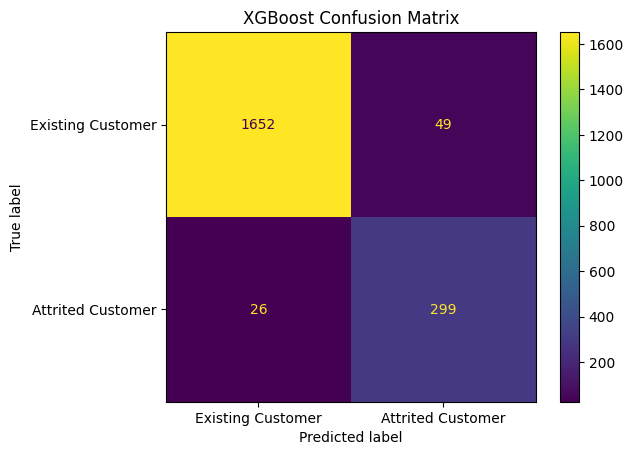

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Existing Customer", "Attrited Customer"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()